In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import pyarrow
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
from datetime import date

In [2]:
features_df = pd.read_parquet(r"..\data\features.parquet", engine="pyarrow")

In [3]:
# Mobile mean with a window of one hour
hours = 1
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_mobile_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_mobile_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_mobile_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

### Training Set

In [4]:
# Select just one month of data
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]
# Filter the first eleven observations with NAs values
features_df_1_month = features_df_1_month.dropna(subset=['energy_mobile_mean'])

In [5]:
# Take descriptive variables
variables = ["energy_mobile_mean",	"kurtosis_mobile_mean", "frequency_index_mobile_mean", "entropy_mobile_mean"]
X = features_df_1_month[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

print(X.shape)

(8883, 4)


In [6]:
# Scale variables
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

Dimensionality Reduction:
PCA

In [7]:
# Create a PCA object and train it
pca = PCA(n_components=3).fit(X)
# Transform the data to the new reducted space
Z = pca.transform(X)
print(Z.shape)

(8883, 3)


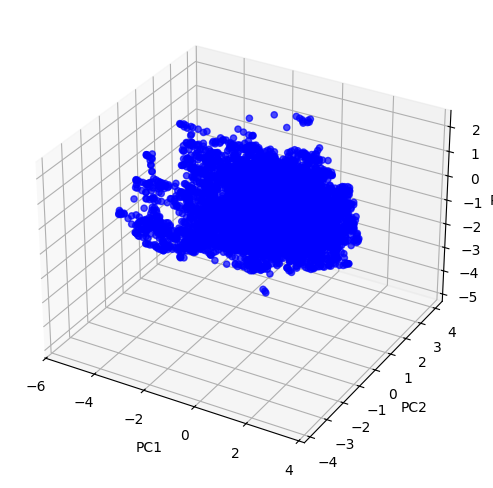

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c='b', s=20, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.grid(True)
plt.show()

### Clustering

In [9]:
km_model = KMeans(n_clusters=3, random_state=9972, n_init=10).fit(Z)

In [10]:
silhouette_score(Z, km_model.labels_)

0.3246819831882183

In [15]:
labels = km_model.labels_

fig = px.scatter_3d(
    x=Z[:, 0],
    y=Z[:, 1],
    z=Z[:, 2],
    color=labels,
    color_continuous_scale='viridis',  # Changed from cmap and added the missing comma
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Cluster'},
    title='Principal Components Analysis Plot (Interactive 3D)',
    opacity=0.8,
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [16]:
# Create a dataframe with the clustering data
clustering_data = pd.DataFrame(Z, columns= ['PC1', 'PC2', 'PC3'])
clustering_data['labels'] = km_model.labels_
# Create a dataframe with the clustering data
km_model.cluster_centers_ = clustering_data.groupby('labels')[['PC1','PC2', 'PC3']].mean().values

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\4112878207.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


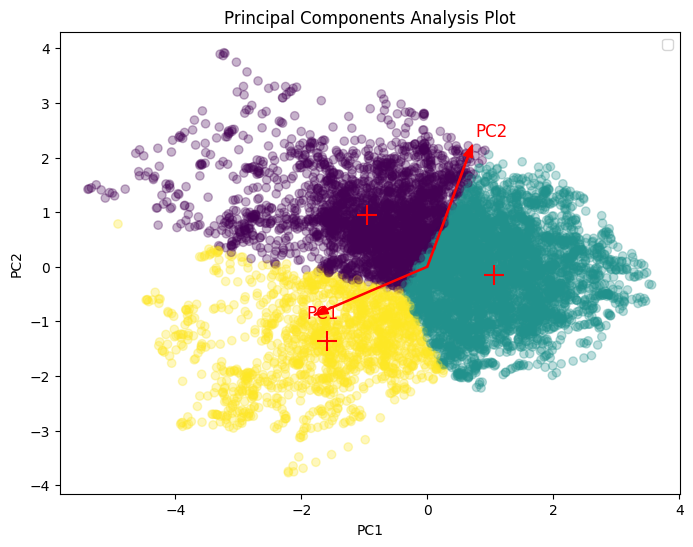

In [17]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='viridis', alpha=0.3)
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(Z[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca.components_[:2], pca.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('Principal Components Analysis Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### Groups Distribution

In [18]:
clustering_data[['labels','PC1']].groupby('labels').count()

,PC1
labels,
0,2775
1,4649
2,1459


### Results Original Data

In [19]:
observed_data = features_df_1_month.copy()
observed_data['labels'] = km_model.labels_

In [20]:
print(observed_data[observed_data['timestamp'].isna()])

Empty DataFrame
Columns: [timestamp, energy, kurtosis, frecuency_index, entropy, frequency_index, energy_mobile_mean, kurtosis_mobile_mean, frequency_index_mobile_mean, entropy_mobile_mean, labels]
Index: []


In [21]:
len(observed_data)

8883

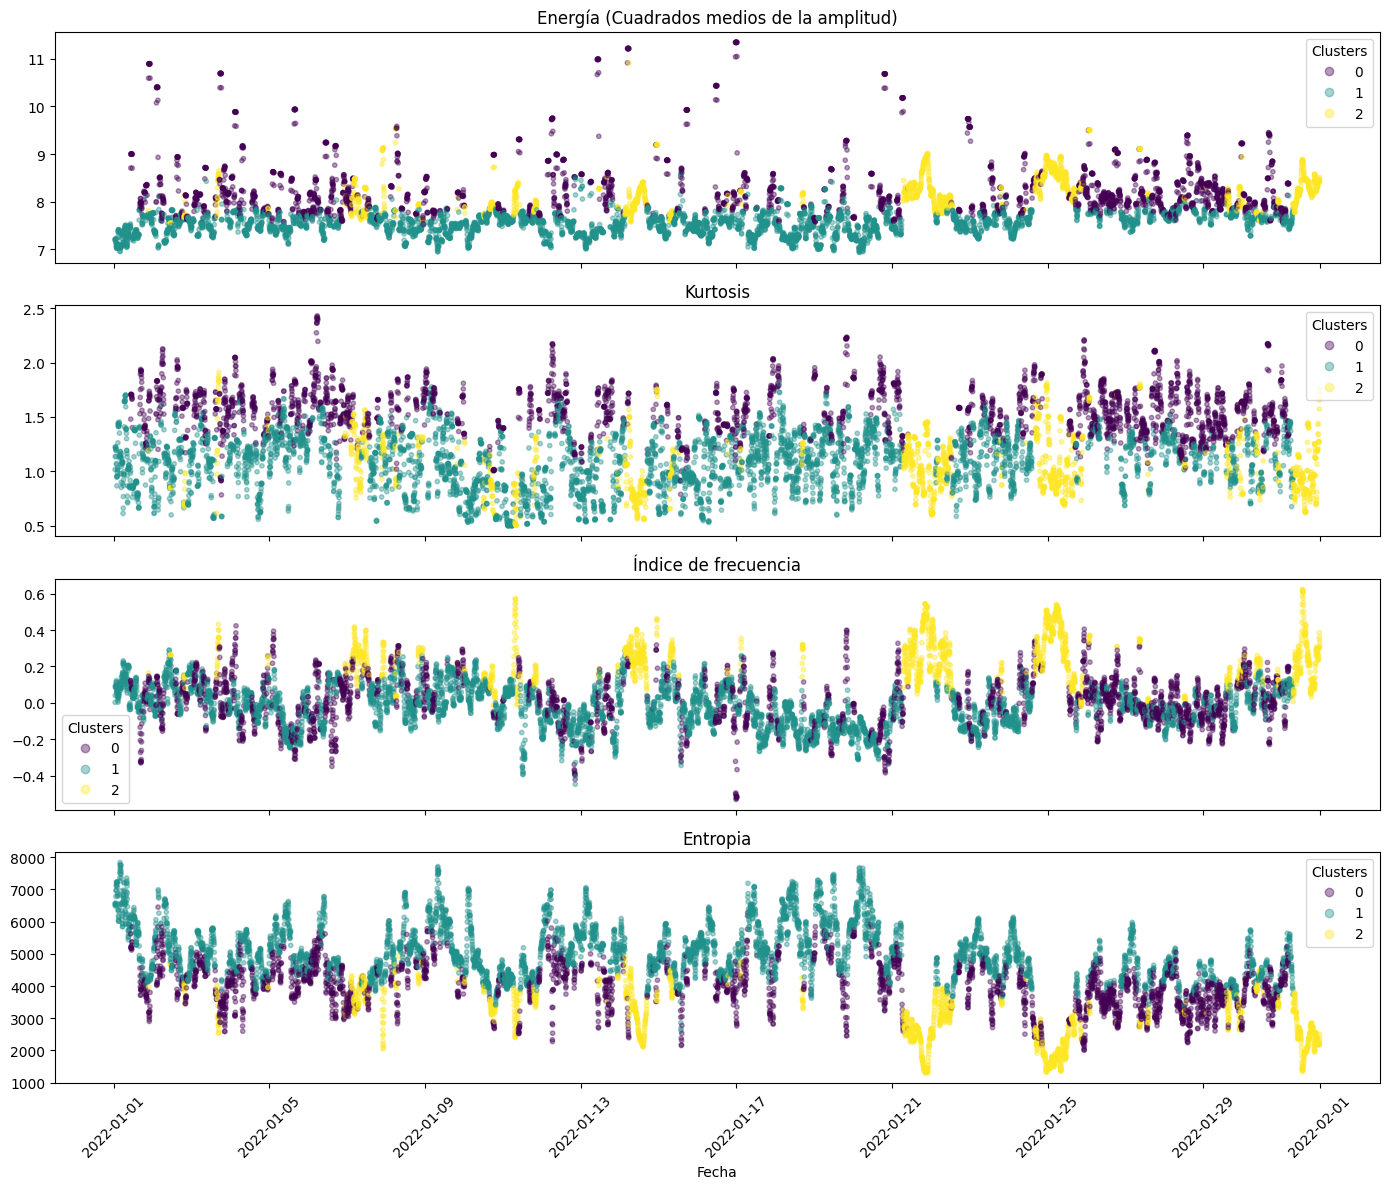

In [22]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(observed_data['timestamp'], observed_data['energy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(observed_data['timestamp'], observed_data['kurtosis_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(observed_data['timestamp'], observed_data['frequency_index_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(observed_data['timestamp'], observed_data['entropy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

Identify Outliers

In [23]:
km_model

KMeans(n_clusters=3, n_init=10, random_state=9972)

In [24]:
distances = km_model.transform(Z)
clustering_data['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model.labels_)]

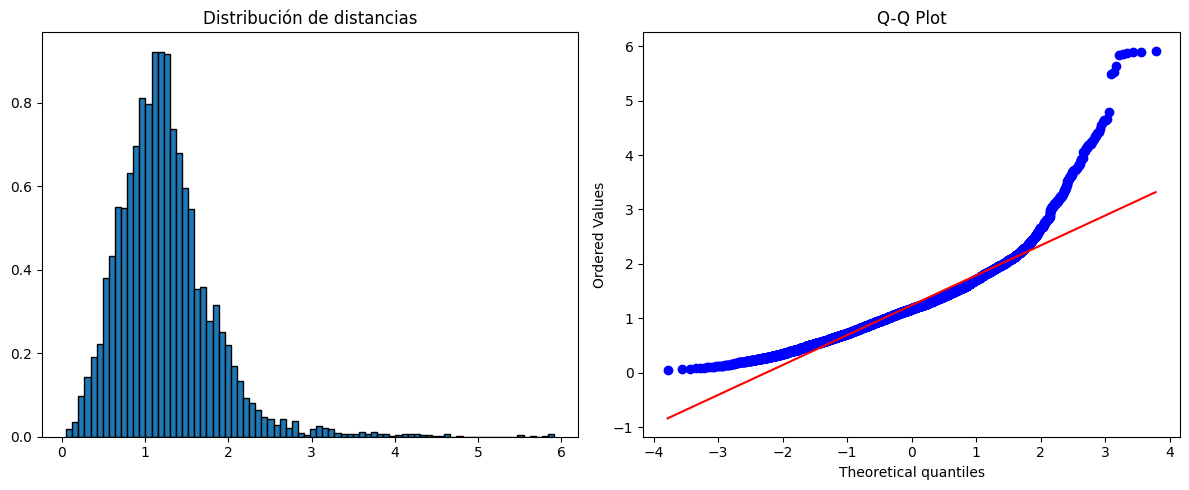

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [26]:
# Rango de valores observados
np.min(clustering_data['distance_to_centroid']),np.max(clustering_data['distance_to_centroid'])

# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3*IQR

In [27]:
print(upper)

3.3945948947895284


In [29]:
# Clasificamos los valores observados como típicos y atípicos
clustering_data['outliers'] = clustering_data['distance_to_centroid'] > 5

In [30]:
clustering_data.head(10)

,PC1,PC2,PC3,labels,distance_to_centroid,outliers
0,2.093583,-0.309114,0.587753,1,1.205685,False
1,1.867200,-0.188118,0.922386,1,1.237926,False
2,1.618884,-0.169109,1.240274,1,1.376366,False
3,1.624468,-0.190031,1.254425,1,1.392096,False
4,1.677512,-0.163761,1.226588,1,1.388604,False
5,1.664216,-0.214508,1.284773,1,1.437030,False
6,1.845154,-0.190238,1.314180,1,1.545753,False
7,2.009945,-0.184887,1.355728,1,1.669037,False
8,1.959393,-0.241060,1.433816,1,1.709182,False
9,2.098498,-0.421087,1.473671,1,1.836875,False


In [31]:
sum(clustering_data['outliers'])

9

### Next Months Forecast

In [32]:
features_df_pred = features_df[(features_df['timestamp']<"2025-01-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_pred = features_df_pred[
    [
        'energy_mobile_mean',
        'kurtosis_mobile_mean',
        'frequency_index_mobile_mean',
        'entropy_mobile_mean'
    ]
]

# Drop rows with missing values
clustering_data_pred.isna().sum()

energy_mobile_mean             0
kurtosis_mobile_mean           0
frequency_index_mobile_mean    0
entropy_mobile_mean            0
dtype: int64

In [33]:
# Scale variables
X_pred = scaler.transform(clustering_data_pred)
# Transform the data to the new reducted space
Z_pred = pca.transform(X_pred)

c:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\Estancia_Maestría\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [34]:
# Predict clusters for new data using the same centroids
labels_pred = km_model.predict(Z_pred)

Outliers in New Data

In [35]:
# Add labels and timestamp to the new dataframe
clustering_data_pred['timestamp'] = features_df_pred['timestamp']
clustering_data_pred['labels'] = labels_pred

distances_pred = km_model.transform(Z_pred)



clustering_data_pred['distance_to_centroid'] = [distances_pred[i, label] for i, label in enumerate(labels_pred)]
clustering_data_pred['outliers'] = clustering_data_pred['distance_to_centroid'] > 5


#clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)
clustering_data_all = clustering_data_pred.copy()


# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\767197663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data_pred['timestamp'] = features_df_pred['timestamp']
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\767197663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data_pred['labels'] = labels_pred
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\767197663.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

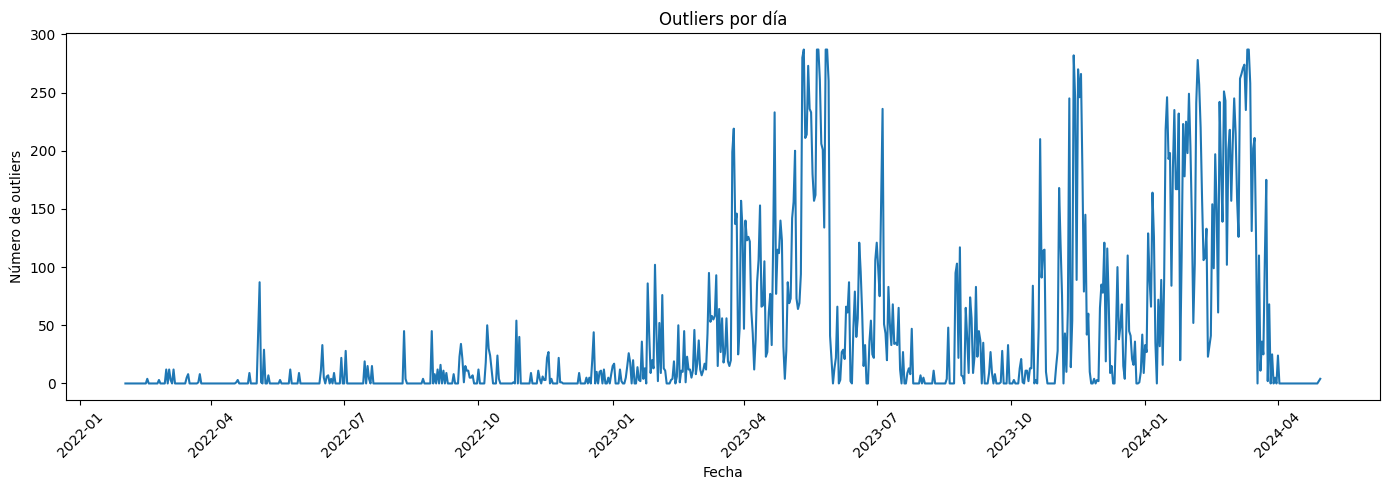

In [ ]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Graficar el RSAM 
## Graficar valores de la segunda derivada (revisar puntos de inflexión)
## Primera derivada entre valores del día anterior o promedio de los últimos n días

In [ ]:
outliers_by_day['rolling_7d'] = outliers_by_day['outliers'].rolling(7).mean()

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'],
         alpha=0.4, label='Diario')
plt.plot(outliers_by_day['date'], outliers_by_day['rolling_7d'],
         linewidth=2, label='Media móvil 7d')
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'outliers'

In [49]:
date_reprocess = outliers_by_day[outliers_by_day['rolling_7d'] > 29]['date'].iloc[0]
date_reprocess

datetime.date(2023, 1, 30)

### Retrain Increase clusters

In [52]:
features_df_increment

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
113073,2023-01-29 23:35:00,8.672853,1.972413,None,1895.027031,-0.499044,9.198108,1.837911,-0.428732,1453.159758
113074,2023-01-29 23:40:00,8.665172,1.095676,None,1790.925623,-0.395475,9.186074,1.824995,-0.448054,1486.014388
113075,2023-01-29 23:45:00,8.989455,1.042851,None,1274.543353,-0.324727,9.121029,1.741188,-0.445040,1520.269300
113076,2023-01-29 23:50:00,8.861711,1.238821,None,1485.861211,-0.168034,9.034869,1.644307,-0.427901,1574.041640


In [54]:
from datetime import timedelta

In [69]:
features_df_increment = features_df_pred[(features_df_pred['timestamp']<= pd.Timestamp(date_reprocess)+ timedelta(days=1))]

clustering_data_increment= features_df_increment[
    [
        'energy_mobile_mean',
        'kurtosis_mobile_mean',
        'frequency_index_mobile_mean',
        'entropy_mobile_mean'
    ]
]#.dropna()

# Drop rows with missing values
clustering_data_increment.isna().sum()

energy_mobile_mean             0
kurtosis_mobile_mean           0
frequency_index_mobile_mean    0
entropy_mobile_mean            0
dtype: int64

In [70]:
# Scale variables
X_increment = scaler.transform(clustering_data_increment)
# Transform the data to the new reducted space
Z_increment = pca.transform(X_increment)

c:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\Estancia_Maestría\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [71]:
labels_increment = km_model.predict(Z_increment)

In [73]:
# Add labels and timestamp to the new dataframe
clustering_data_increment['timestamp'] = features_df_increment['timestamp']
clustering_data_increment['labels'] = labels_increment

distances_increment = km_model.transform(Z_increment)



clustering_data_increment['distance_to_centroid'] = [distances_increment[i, label] for i, label in enumerate(labels_increment)]
clustering_data_increment['outliers'] = clustering_data_increment['distance_to_centroid'] > 5


#clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)
clustering_data_all_2 = clustering_data_increment.copy()


# Optional: sort by timestamp
clustering_data_all_2 = clustering_data_all_2.sort_values('timestamp')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\800819994.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data_increment['timestamp'] = features_df_increment['timestamp']
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\800819994.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data_increment['labels'] = labels_increment
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\800819994.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [80]:
clustering_data_increment.columns

Index(['energy_mobile_mean', 'kurtosis_mobile_mean',
       'frequency_index_mobile_mean', 'entropy_mobile_mean', 'timestamp',
       'labels', 'distance_to_centroid', 'outliers'],
      dtype='object')

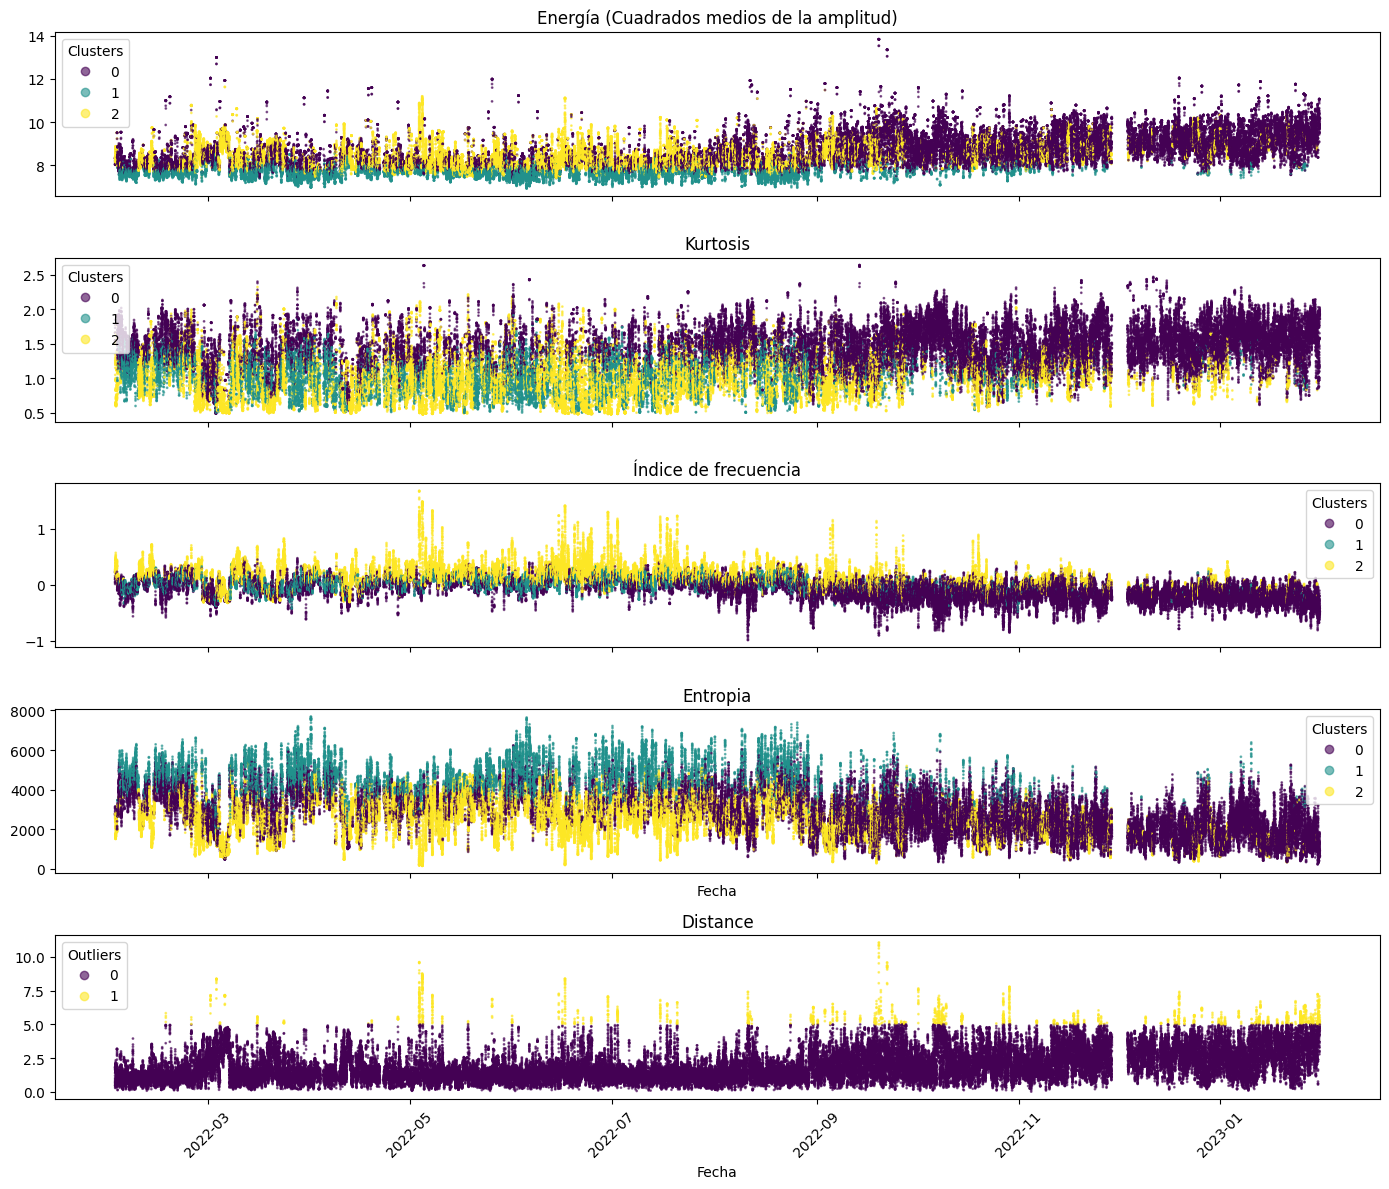

In [77]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_increment['timestamp'], clustering_data_increment['energy_mobile_mean'], c=clustering_data_increment['labels'], cmap='viridis', s=1, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_increment['timestamp'], clustering_data_increment['kurtosis_mobile_mean'], c=clustering_data_increment['labels'], cmap='viridis', s=1, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_increment['timestamp'], clustering_data_increment['frequency_index_mobile_mean'], c=clustering_data_increment['labels'], cmap='viridis', s=1, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_increment['timestamp'], clustering_data_increment['entropy_mobile_mean'], c=clustering_data_increment['labels'], cmap='viridis', s=1, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_increment['timestamp'], clustering_data_increment['distance_to_centroid'], c=clustering_data_increment['outliers'], s=1, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [84]:
buffer = clustering_data_increment[clustering_data_increment['outliers']].copy()[
    [
        'energy_mobile_mean',
        'kurtosis_mobile_mean',
        'frequency_index_mobile_mean',
        'entropy_mobile_mean'
    ]
]

# Scale variables
X_buffer = scaler.transform(buffer)
# Transform the data to the new reducted space
Z_buffer = pca.transform(X_buffer)

print(f"Outliers en buffer: {len(buffer)}")

Outliers en buffer: 1742


c:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\Estancia_Maestría\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [85]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model_aux = KMeans(n_clusters=k).fit(Z_buffer)
  inertia.append(km_model_aux.inertia_)
  silh.append(silhouette_score(Z_buffer, km_model_aux.labels_))

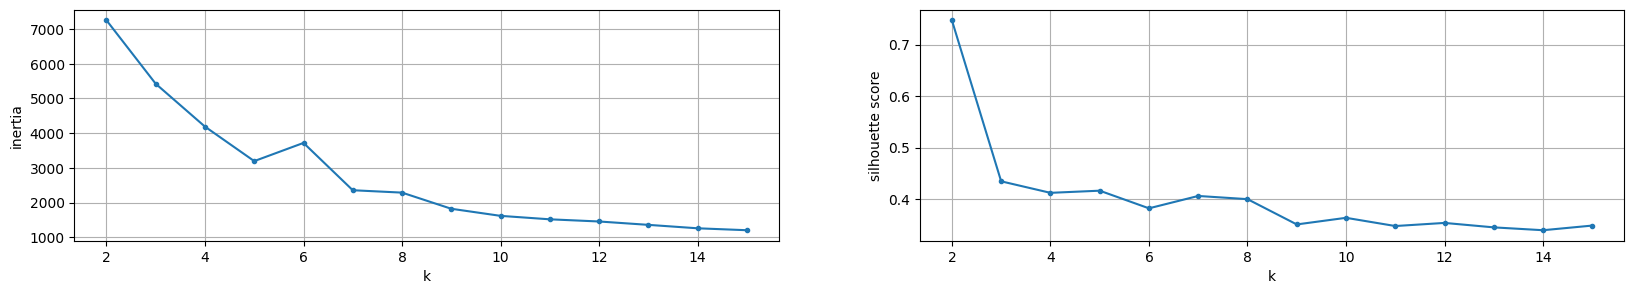

In [86]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [88]:
n_original = len(km_model.cluster_centers_)
n_original

3

In [91]:
km_model_buffer = KMeans(n_clusters=3).fit(Z_buffer)

len(km_model_buffer.cluster_centers_)

3

In [92]:
# Create a dataframe with the clustering data
clustering_data_buffer = pd.DataFrame(Z_buffer, columns= ['PC1', 'PC2', 'PC3'])
clustering_data_buffer['labels'] = km_model_buffer.labels_
# Create a dataframe with the clustering data


In [94]:
clustering_data_buffer[['labels','PC1']].groupby('labels').count()

,PC1
labels,
0,435
1,408
2,899


In [95]:
MIN_MIEMBROS = 20   # ajusta según lo que viste arriba

n_original = len(km_model.cluster_centers_)
promover = []   # índices del buffer que sí se promueven

for k in range(km_model_buffer.n_clusters):
    n = (km_model_buffer.labels_ == k).sum()
    if n >= MIN_MIEMBROS:
        promover.append(k)
        print(f"✓ Buffer {k} ({n} miembros) → será Cluster {n_original + len(promover) - 1}")
    else:
        print(f"✗ Buffer {k} ({n} miembros) → descartado, queda como anomalía")

✓ Buffer 0 (435 miembros) → será Cluster 3
✓ Buffer 1 (408 miembros) → será Cluster 4
✓ Buffer 2 (899 miembros) → será Cluster 5


In [96]:
mapping = {}   # {label_buffer: label_global}
for i, k in enumerate(promover):
    mapping[k] = n_original + i

print("Mapeo buffer → global:", mapping)

Mapeo buffer → global: {0: 3, 1: 4, 2: 5}


In [97]:
nuevos_centroides = km_model_buffer.cluster_centers_[promover]

centroides_expandidos = np.vstack([
    km_model.cluster_centers_,
    nuevos_centroides
])

print(f"Centroides: {n_original} → {len(centroides_expandidos)}")

Centroides: 3 → 6


In [98]:
buffer_labels_globales = np.array([
    mapping.get(lbl, -1) for lbl in km_model_buffer.labels_
])

buffer['labels_nuevo'] = buffer_labels_globales

print(pd.Series(buffer_labels_globales).value_counts().sort_index())

3    435
4    408
5    899
Name: count, dtype: int64


In [99]:
# Inicializar con los labels originales
clustering_data_increment['labels_final'] = clustering_data_increment['labels']

# Sobrescribir solo las filas del buffer, usando el índice
clustering_data_increment.loc[buffer.index, 'labels_final'] = buffer['labels_nuevo']

# Marcar quién sigue siendo anomalía
clustering_data_increment['outliers_final'] = clustering_data_increment['labels_final'] == -1

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11080\2750861991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data_increment['labels_final'] = clustering_data_increment['labels']


In [100]:
clustering_data_increment

,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp,labels,distance_to_centroid,outliers,labels_final,outliers_final
8897,8.393811,1.661201,0.273803,2568.654698,2022-02-01 00:05:00,2,1.830622,False,2,False
8898,8.368427,1.661031,0.251328,2632.398663,2022-02-01 00:10:00,2,1.809466,False,2,False
8899,8.331916,1.660930,0.233178,2718.468674,2022-02-01 00:15:00,0,1.725136,False,0,False
8900,8.318658,1.660575,0.221038,2781.344684,2022-02-01 00:20:00,0,1.631353,False,0,False
8901,8.329291,1.775273,0.159708,2764.549794,2022-02-01 00:25:00,0,1.386021,False,0,False
...,...,...,...,...,...,...,...,...,...,...
113360,10.182735,1.939679,-0.506853,647.217114,2023-01-30 23:35:00,0,5.348798,True,5,False
113361,10.152950,1.863353,-0.482147,663.726053,2023-01-30 23:40:00,0,5.186783,True,5,False
113362,10.167066,1.887686,-0.472201,613.213958,2023-01-30 23:45:00,0,5.197964,True,5,False
113363,10.154265,1.863308,-0.419098,679.936516,2023-01-30 23:50:00,0,4.972933,False,0,False


In [101]:
n_antes = clustering_data_increment['outliers'].sum()
n_despues = clustering_data_increment['outliers_final'].sum()

print(f"Outliers antes:   {n_antes}")
print(f"Outliers después: {n_despues}")
print(f"Absorbidos:       {n_antes - n_despues}\n")

print(clustering_data_increment['labels_final'].value_counts().sort_index())

Outliers antes:   1742
Outliers después: 0
Absorbidos:       1742

labels_final
0    51031
1    17888
2    30402
3      435
4      408
5      899
Name: count, dtype: int64


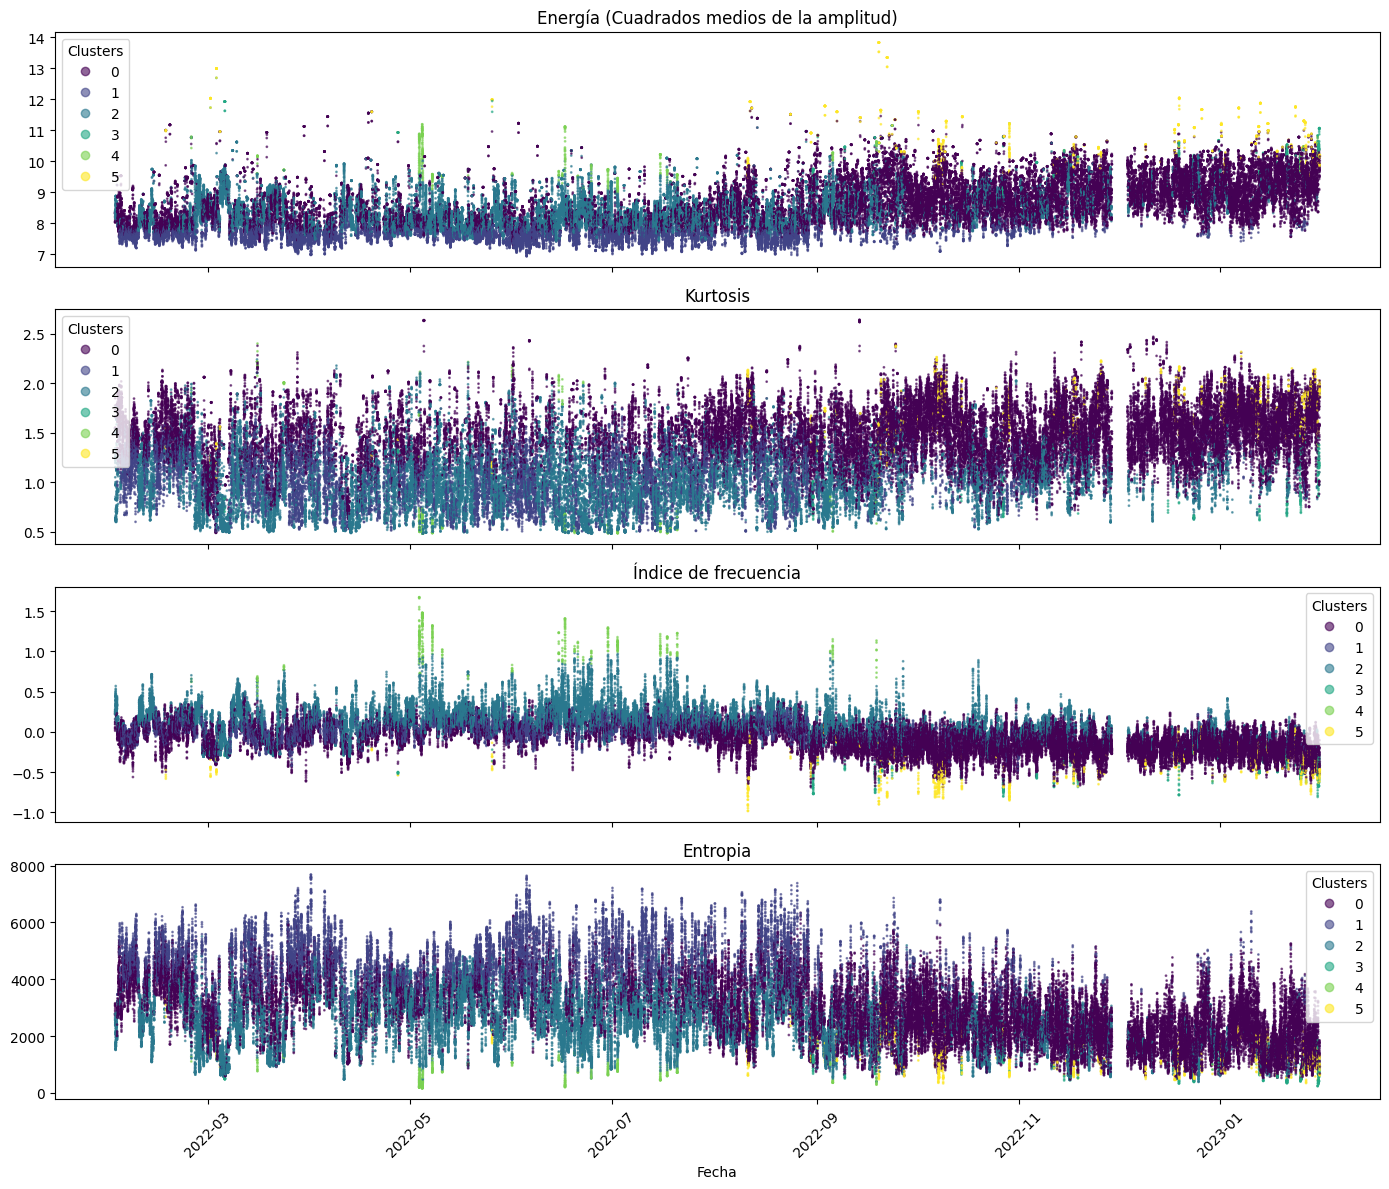

In [102]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_increment['timestamp'], clustering_data_increment['energy_mobile_mean'], c=clustering_data_increment['labels_final'], cmap='viridis', s=1, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_increment['timestamp'], clustering_data_increment['kurtosis_mobile_mean'], c=clustering_data_increment['labels_final'], cmap='viridis', s=1, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_increment['timestamp'], clustering_data_increment['frequency_index_mobile_mean'], c=clustering_data_increment['labels_final'], cmap='viridis', s=1, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_increment['timestamp'], clustering_data_increment['entropy_mobile_mean'], c=clustering_data_increment['labels_final'], cmap='viridis', s=1, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")



plt.xticks(rotation=45)
plt.tight_layout()

In [116]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min


closest, dists = pairwise_distances_argmin_min(Z_increment, centroides_expandidos)

clustering_data_increment['labels_expanded'] = closest
clustering_data_increment['distance_expanded'] = dists

In [117]:
clustering_data_increment

,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp,labels,distance_to_centroid,outliers,labels_final,outliers_final,labels_expanded,distance_expanded
8897,8.393811,1.661201,0.273803,2568.654698,2022-02-01 00:05:00,2,1.830622,False,2,False,2,1.830622
8898,8.368427,1.661031,0.251328,2632.398663,2022-02-01 00:10:00,2,1.809466,False,2,False,2,1.809466
8899,8.331916,1.660930,0.233178,2718.468674,2022-02-01 00:15:00,0,1.725136,False,0,False,0,1.725136
8900,8.318658,1.660575,0.221038,2781.344684,2022-02-01 00:20:00,0,1.631353,False,0,False,0,1.631353
8901,8.329291,1.775273,0.159708,2764.549794,2022-02-01 00:25:00,0,1.386021,False,0,False,0,1.386021
...,...,...,...,...,...,...,...,...,...,...,...,...
113360,10.182735,1.939679,-0.506853,647.217114,2023-01-30 23:35:00,0,5.348798,True,5,False,5,0.488257
113361,10.152950,1.863353,-0.482147,663.726053,2023-01-30 23:40:00,0,5.186783,True,5,False,5,0.458827
113362,10.167066,1.887686,-0.472201,613.213958,2023-01-30 23:45:00,0,5.197964,True,5,False,5,0.438158
113363,10.154265,1.863308,-0.419098,679.936516,2023-01-30 23:50:00,0,4.972933,False,0,False,5,0.640700


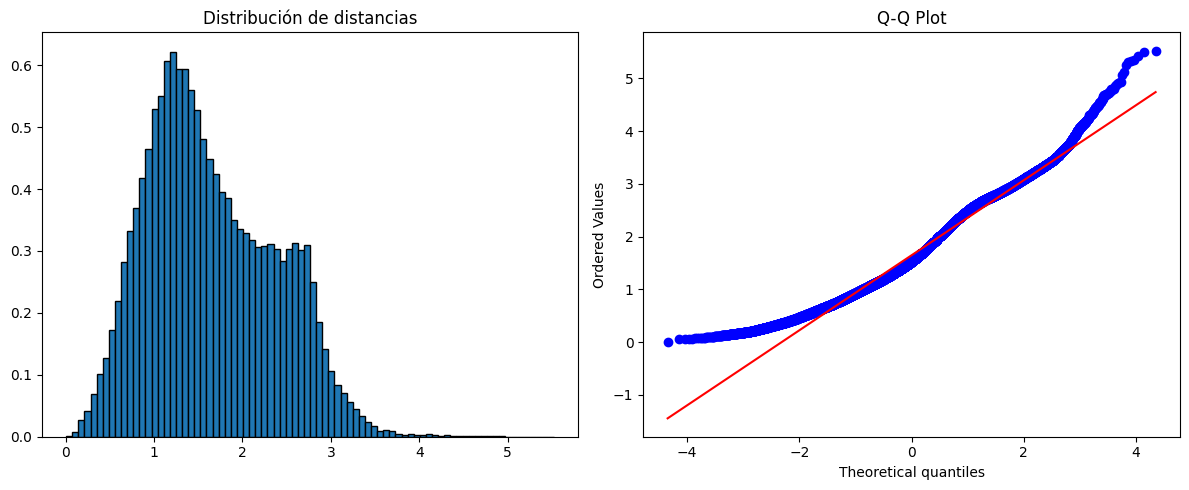

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data_increment['distance_expanded'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data_increment['distance_expanded'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [121]:
np.min(clustering_data_increment['distance_expanded']),np.max(clustering_data_increment['distance_expanded'])

# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data_increment['distance_expanded'].quantile(0.25)
Q3 = clustering_data_increment['distance_expanded'].quantile(0.75)
IQR = Q3 - Q1
upper_increment = Q3 + 3*IQR

upper_increment

5.455639177883942

In [122]:
clustering_data_increment['outliers_new'] = clustering_data_increment['distance_expanded'] > upper_increment


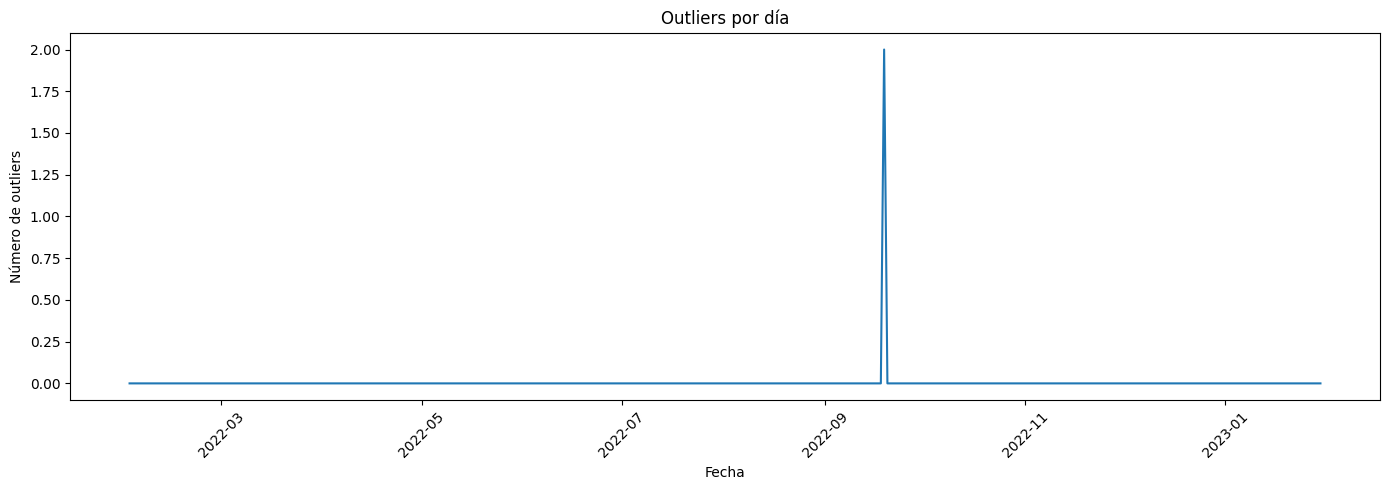

In [123]:
clustering_data_increment['date'] = pd.to_datetime(clustering_data_increment['timestamp']).dt.date

total_by_day = clustering_data_increment.groupby('date').size()
outliers_by_day = (clustering_data_increment[clustering_data_increment['outliers_new'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers_new']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers_new'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [124]:
closest, dists = pairwise_distances_argmin_min(Z_pred, centroides_expandidos)

clustering_data_all['labels_expanded'] = closest
clustering_data_all['distance_expanded'] = dists

In [125]:
clustering_data_all['outliers_new'] = clustering_data_all['distance_expanded'] > upper_increment


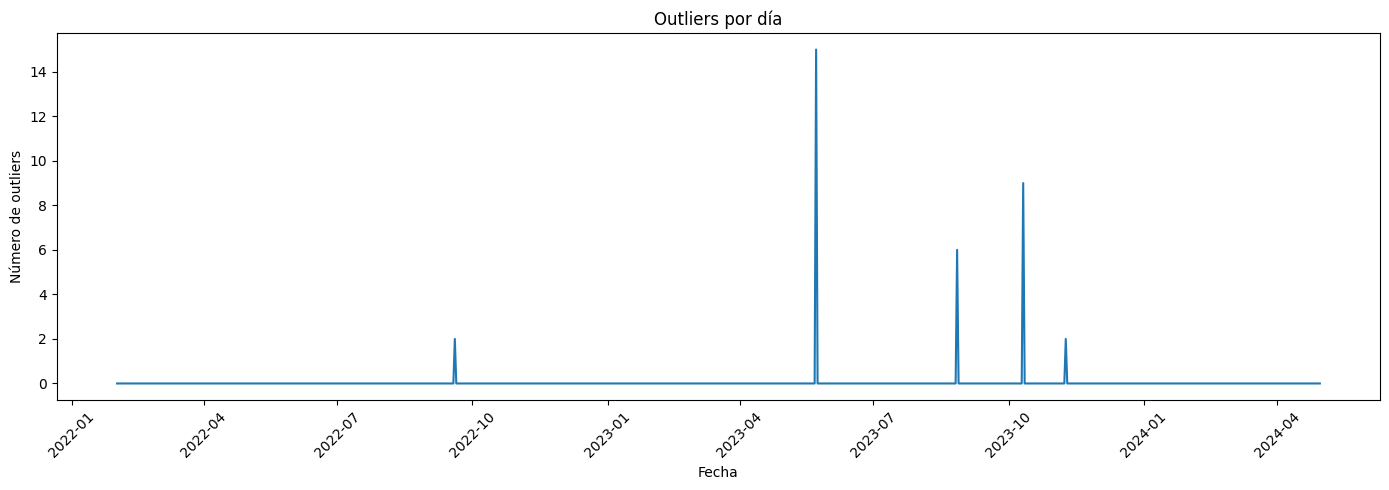

In [126]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers_new'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers_new']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers_new'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

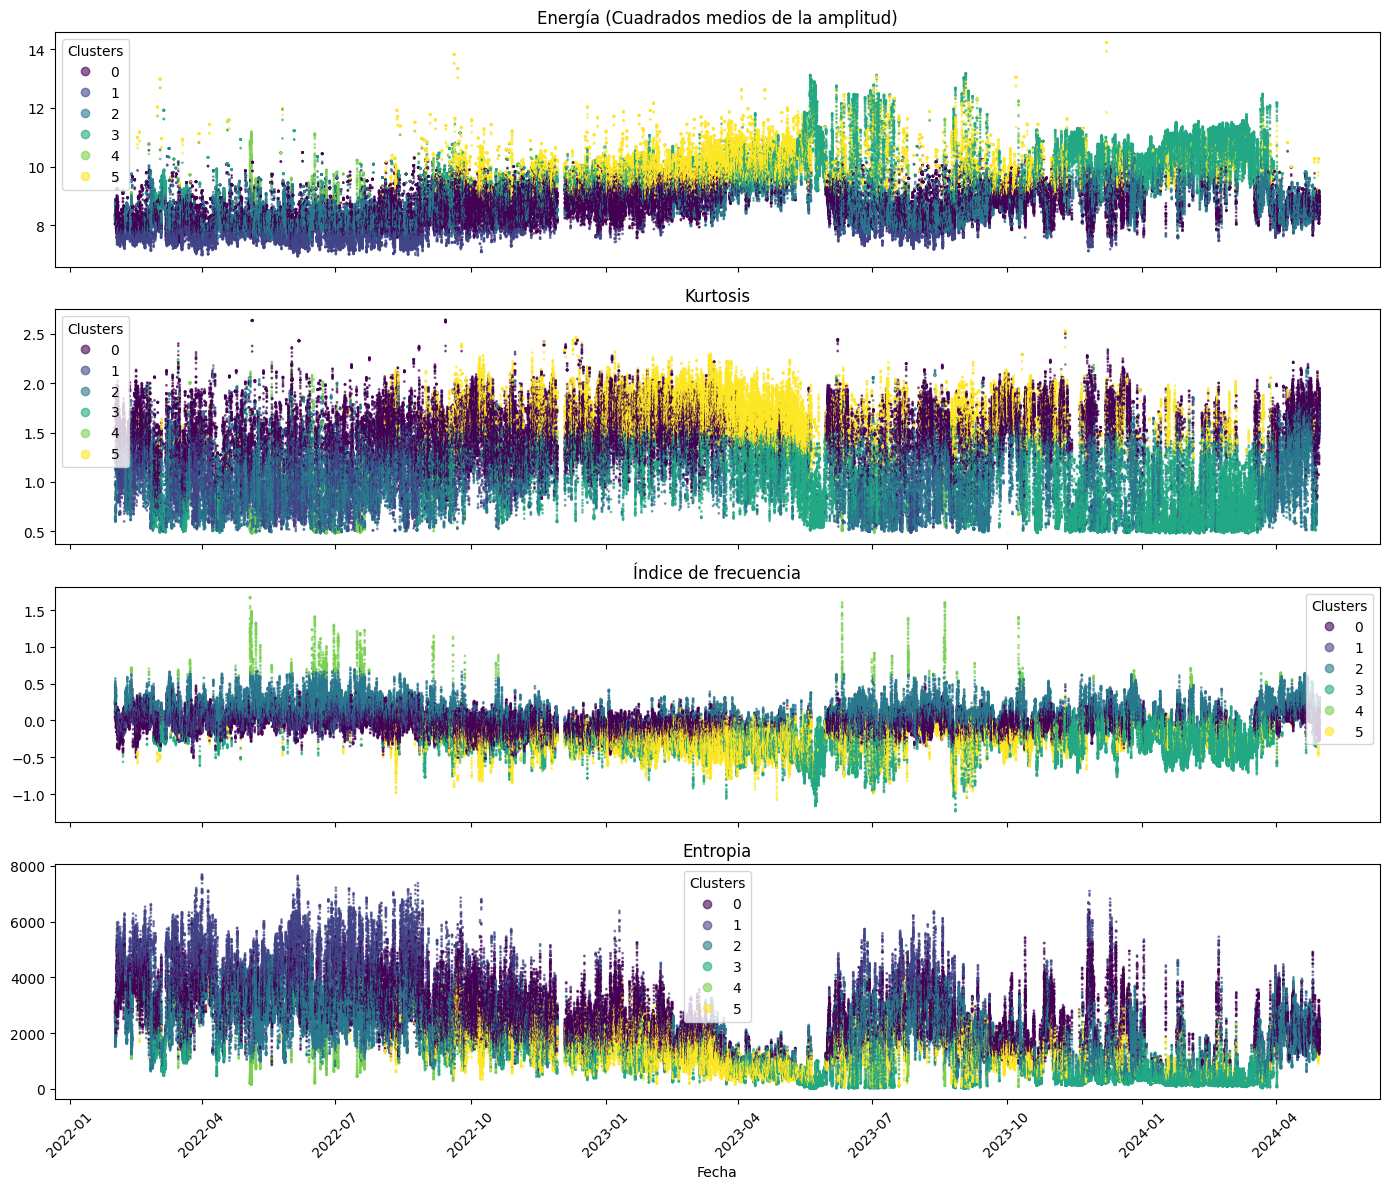

In [114]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_mobile_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=1, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=1, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_mobile_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=1, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_mobile_mean'], c=clustering_data_all['labels_expanded'], cmap='viridis', s=1, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")



plt.xticks(rotation=45)
plt.tight_layout()

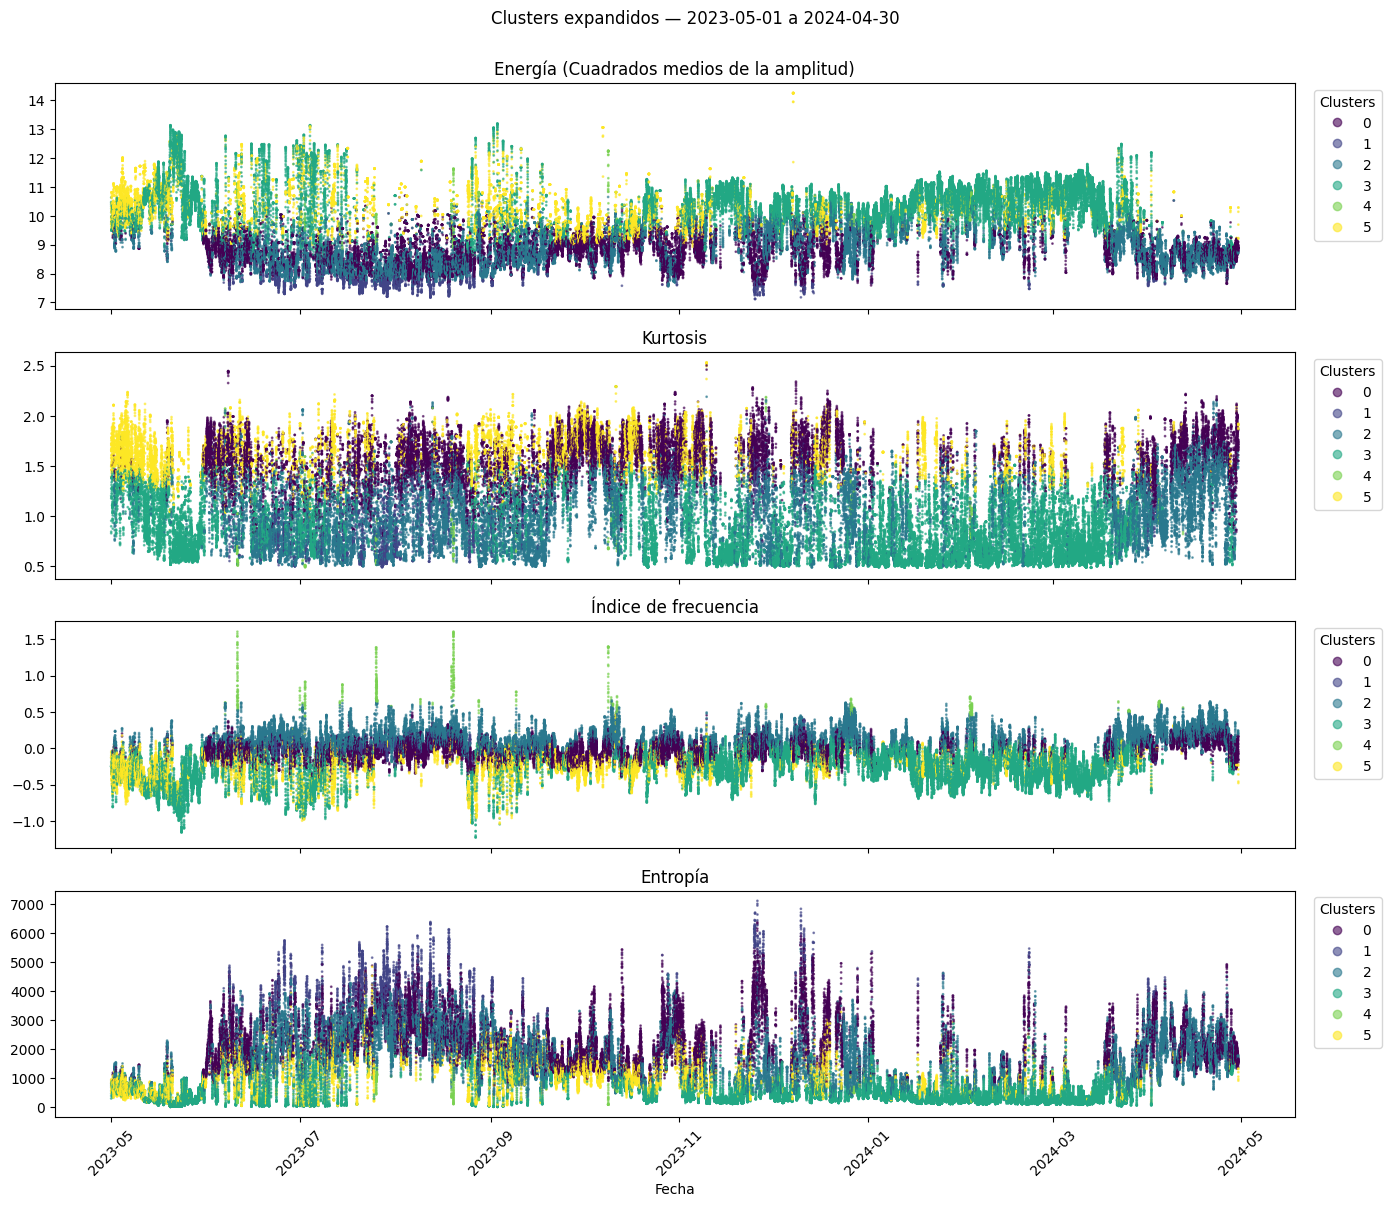

In [129]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Filtro de fechas ─────────────────────────────────────────────
fecha_inicio = "2023-05-01"
fecha_fin    = "2024-04-30"

df_plot = clustering_data_all[
    (clustering_data_all['timestamp'] >= fecha_inicio) &
    (clustering_data_all['timestamp'] <= fecha_fin)
]

# ── Plot ─────────────────────────────────────────────────────────
features = [
    ('energy_mobile_mean',           'Energía (Cuadrados medios de la amplitud)'),
    ('kurtosis_mobile_mean',         'Kurtosis'),
    ('frequency_index_mobile_mean',  'Índice de frecuencia'),
    ('entropy_mobile_mean',          'Entropía'),
]

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

for ax, (col, titulo) in zip(axes, features):
    scatter = ax.scatter(
        df_plot['timestamp'], df_plot[col],
        c=df_plot['labels_expanded'], cmap='viridis', s=1, alpha=0.6
    )
    ax.set_title(titulo)
    ax.legend(*scatter.legend_elements(), title="Clusters",
              loc='upper left', bbox_to_anchor=(1.01, 1))

axes[-1].set_xlabel('Fecha')

fig.suptitle(f'Clusters expandidos — {fecha_inicio} a {fecha_fin}', y=1.002)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()